In [36]:
# coding: utf-8
import sys, os

import numpy as np
from numba import jit
import matplotlib.pyplot as plt
# from dataset.mnist import load_mnist
from simple_convnet import SimpleConvNet
from common.trainer import Trainer


In [ ]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient
from numba import jit


class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def numerical_gradient(self, x, t):
        """기울기를 구한다（수치미분）.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_w = lambda w: self.loss(x, t)

        grads = {}
        for idx in (1, 2, 3):
            grads['W' + str(idx)] = numerical_gradient(loss_w, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_w, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]



In [37]:
test_dict = {}
train_dict = {}
root_path = '../datasets/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) or pytorch-standard (N, C, H ,W) shape, run following codes.
def numpy2rgb(arr: np.ndarray, way='torch') -> np.ndarray:
    batch_size = len(arr)
    if way == 'numpy':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    elif way == 'torch':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,1,2,3)
        
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [38]:
@jit(nopython=True)
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [39]:
x_train, t_train = normalize(train_dict[b'data']), train_dict[b'labels']
x_test, t_test = normalize(test_dict[b'data']), test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 3, 32, 32)
2.0934103819823675
(50000,)


In [40]:
x_train, t_train = x_train[:10000], t_train[:10000]
x_test, t_test = x_test[:10000], t_test[:10000]

In [41]:
network_dict = {
                'simpleConv': SimpleConvNet(input_dim=(3,32,32),
                                            conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                                            hidden_size=100, output_size=10, weight_init_std=0.01)
                }

In [42]:
# net = network_dict['simpleConv']
# print(net.layers)
# N, C, H, W = x_train[:10].shape
# print(net.params['W1'].shape)
# out_h = (H + 2*0 - 5)//1 + 1
# out_w = (W + 2*0 - 5)//1 + 1
# print(out_h, out_w)

In [43]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [44]:
@jit(nopython=True)
def train(key, network, output_dict):
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
            
        return None

In [45]:
output_dict = {}
for key, network in network_dict.items():

    train(key, network, output_dict)
        
    print('='*10)
    print('\n\n')


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mnon-precise type pyobject[0m
[0m[1mDuring: typing of argument at C:\Users\dieyo\AppData\Local\Temp\ipykernel_19904\1768535327.py (1)[0m
[1m
File "..\..\..\..\..\AppData\Local\Temp\ipykernel_19904\1768535327.py", line 1:[0m
[1m<source missing, REPL/exec in use?>[0m 

This error may have been caused by the following argument(s):
- argument 1: [1mCannot determine Numba type of <class 'simple_convnet.SimpleConvNet'>[0m
- argument 2: [1mCannot determine Numba type of <class 'dict'>[0m


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


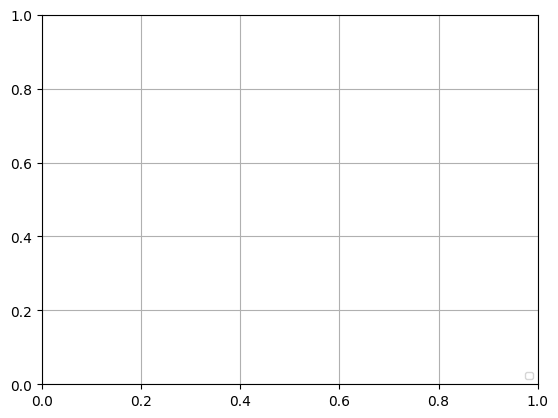

In [ ]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right', prop={'size':7})
plt.grid()